# **MÓDULO 33 - Projeto Final de Modelos Avançados**

**O dataset a ser utilizado neste projeto contém informações de 200 clientes, com os seguintes atributos:**

CustomerID: Identificador único atribuído a cada cliente.

Gender: Gênero do cliente.

Age: Idade do cliente.

Annual Income (k$): Renda anual do cliente em milhares de dólares.

Spending Score (1-100): Pontuação atribuída pelo shopping com base no
comportamento e padrão de gastos do cliente.

## 1 - Importando Bibliotecas:

In [1]:
%matplotlib widget

#Manipulação do DF:
import numpy as np 
import pandas as pd 

#Ferramentas gráficas
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly as py

#Clusterização + visual 3D
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objs as go

#Ignorar warnings
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

## 2 - Carregando e explorando os dados

In [2]:
df = pd.read_csv("Mall_Customers.csv", delimiter=',')

In [3]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


Nesta etapa vamos verificar os tipos de dados e métricas estatísticas iniciais para entender quais tratamentos necessários:

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


Após a verificação identificamos que será necessario apenas simplificar as nomenclaturas das colunas e transformar a coluna Gender em booleana:

In [6]:
# Simplificando a nomenclatura das colunas
df = df.rename(columns={'Annual Income (k$)': 'Annual_income', 'Spending Score (1-100)': 'Spending_score'})

In [7]:
#Transformando a coluna de genero em booleana
df['Gender'].replace(['Female','Male'], [0,1],inplace=True)

C:\Users\gsuti\AppData\Local\Temp\ipykernel_8428\3582913701.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].replace(['Female','Male'], [0,1],inplace=True)
C:\Users\gsuti\AppData\Local\Temp\ipykernel_8428\3582913701.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender'].rep

In [8]:
#Verificando as alterações
df.head()

,CustomerID,Gender,Age,Annual_income,Spending_score
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


## 3 - Visualização gráfica dos  dados

Nesta etapa iremos plotar alguns gráficos para começar a entender melhor a base de dados e começar a gerar insights que colaborem coma a análise:

1 - Proporção entre clientes homens e mulheres

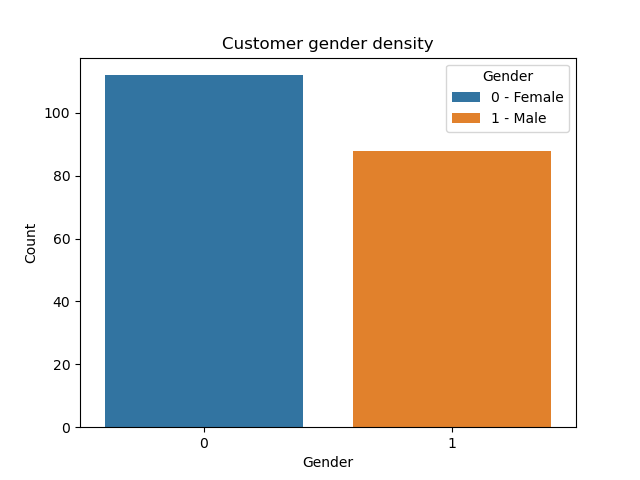

In [9]:
ax = sns.countplot(x='Gender', hue='Gender', data=df, legend=True)

# Personaliza o título e os rótulos dos eixos
plt.title('Customer gender density')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Gender', labels=['0 - Female', '1 - Male'])

Há uma leve disparidade de genero pendendo mais para o publico feminino, vamos explorar outras variávies ainda com um olhar para o gênero para verificar se há alguma interação.

2 - Histogramas com a contagem de clientes por faixa de idade, annual_income e spending_score

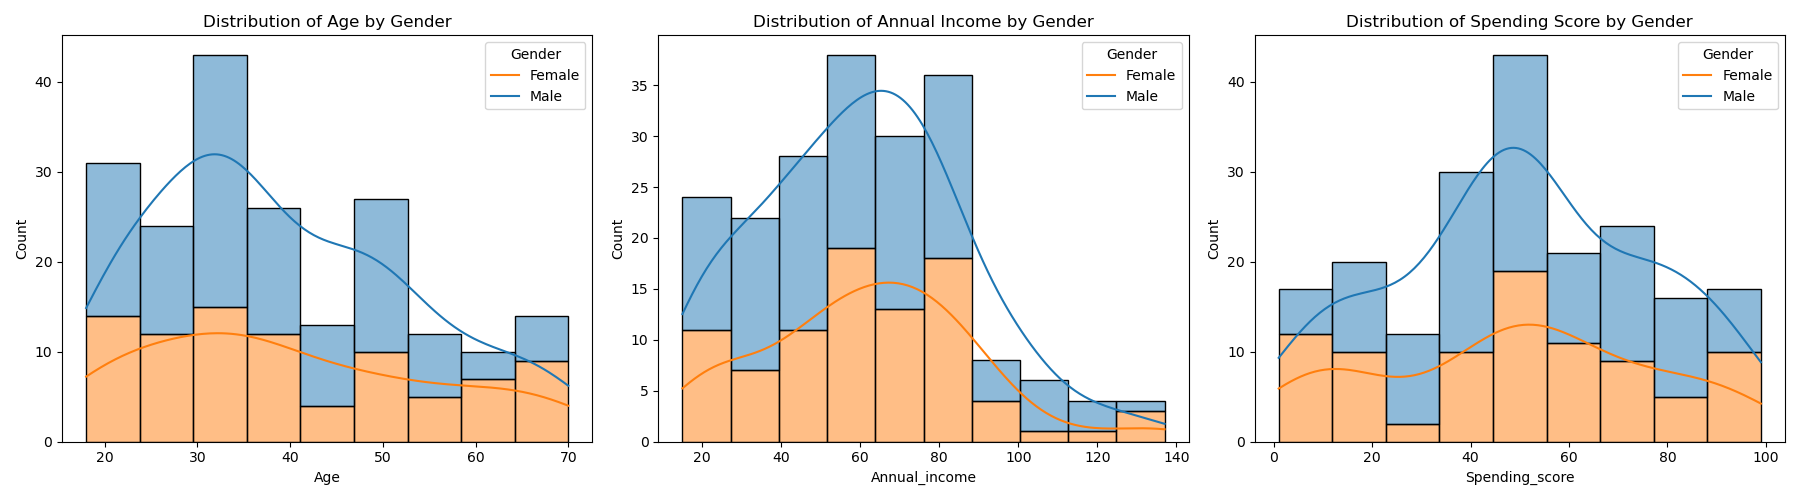

In [10]:
# Configura uma janela com 3 subplots lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histograma para Idade (Age)
sns.histplot(data=df, x='Age', hue='Gender', multiple='stack', kde=True, ax=axes[0])
axes[0].set_title('Distribution of Age by Gender')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend(title='Gender', labels=['Female', 'Male'])

# 2. Histograma para Renda Anual (Annual Income)
sns.histplot(data=df, x='Annual_income', hue='Gender', multiple='stack', kde=True, ax=axes[1])
axes[1].set_title('Distribution of Annual Income by Gender')
axes[1].set_xlabel('Annual_income')
axes[1].set_ylabel('Count')
axes[1].legend(title='Gender', labels=['Female', 'Male'])

# 3. Histograma para Pontuação de Gastos (Spending Score)
sns.histplot(data=df, x='Spending_score', hue='Gender', multiple='stack', kde=True, ax=axes[2])
axes[2].set_title('Distribution of Spending Score by Gender')
axes[2].set_xlabel('Spending_score')
axes[2].set_ylabel('Count')
axes[2].legend(title='Gender', labels=['Female', 'Male'])

# Ajusta o espaçamento entre os gráficos
plt.tight_layout()
plt.show()

3 - Matriz de correlação com heapmap

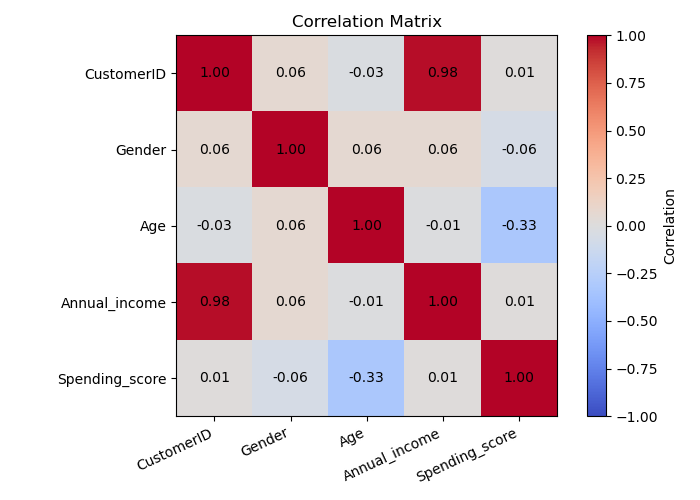

In [11]:
# Correlation heatmap using matplotlib
corr = df.corr()
plt.figure(figsize=(7, 5))
plt.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=25, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


Visto que a maior correlação encontrada foi entre a idade e o spending_score vamos explorar um pouco mais essa interação.

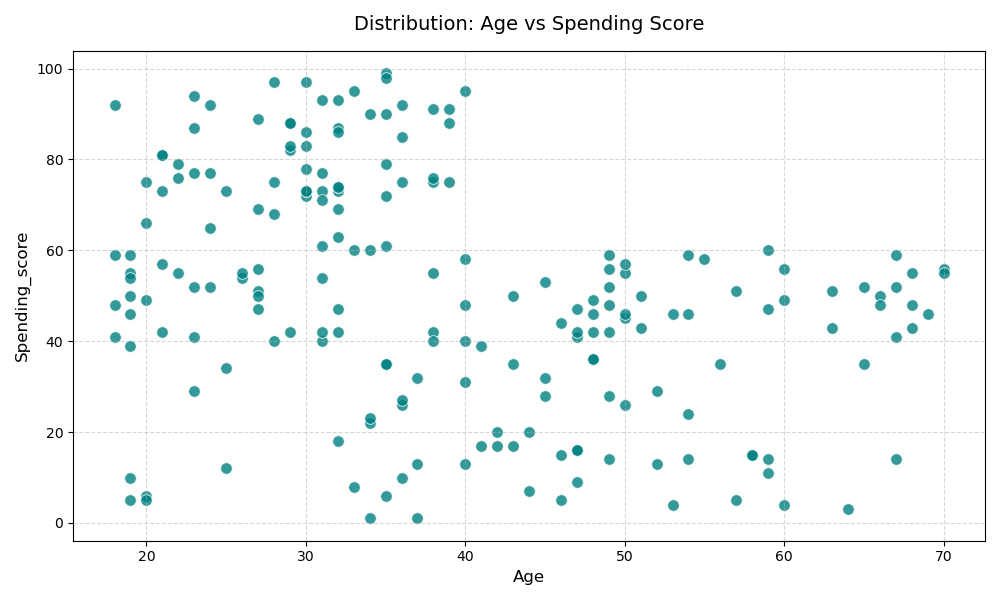

In [12]:
plt.figure(figsize=(10, 6))

# Gráfico de dispersão puro, sem distinção de gênero
sns.scatterplot(
    data=df,
    x='Age',
    y='Spending_score',
    color='teal',  # Uma cor única para todos os pontos
    s=70,          # Tamanho dos pontos
    alpha=0.8,
)

# Customizações do gráfico
plt.title('Distribution: Age vs Spending Score', fontsize=14, pad=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Spending_score', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5) 
plt.tight_layout()
plt.show()

Percebe-se que surge um vazio no quartil superior direito indicando que conforme avançamos na idade dos clientes não vimos um aumento no spengin_score, sendo inclusive os clientes com maior spending_score na faixa de 20 à 40 anos.

Na sequência iremos clusterizar os clientes com base em age, spending_score e annual_income. Dispensaremos nesta etapa a diferenciação por genêro pois ela não parece afetar muito o comportamento das demias variáveis e sua inclusão deve acarretar na dobra da quantidade de clusters sem um ganho na classificação do comportamento do cliente.

## 4 - Clusterização com K-MEANS

In [13]:
#Padronização
features = ["Annual_income", "Spending_score"]
X = df[features]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

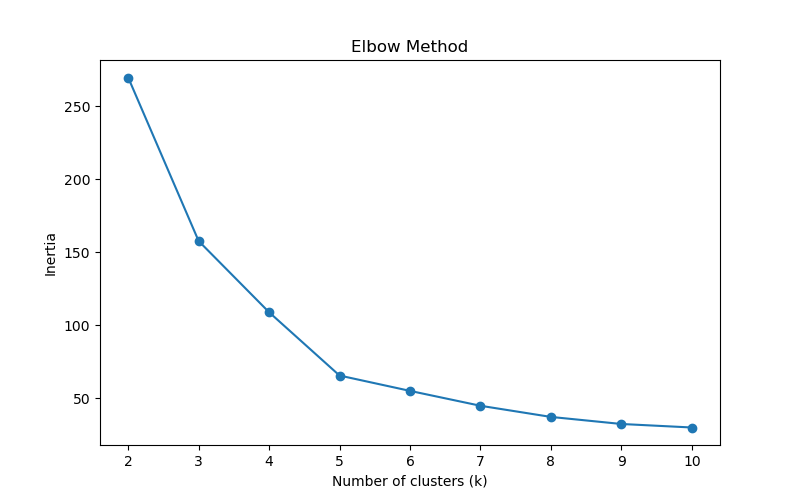

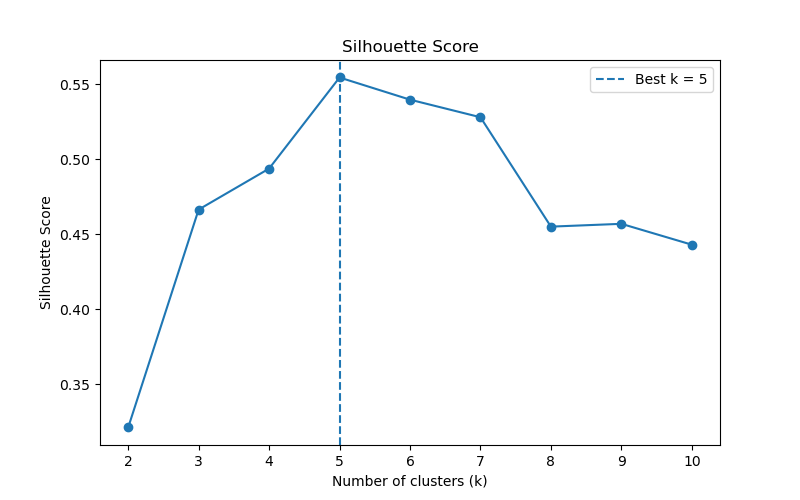


Recomendação de numero de clusters: 5
Coluna 'Cluster' criada com sucesso! Grupos encontrados: [4 2 0 1 3]


In [21]:
# Gerar gráficos Elbow e Silhouette
K = range(2, 11)
inertias = []
silhouettes = []

for k in K:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8, 5))
plt.plot(list(K), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(list(K))
plt.show()

best_k = list(K)[silhouettes.index(max(silhouettes))]

plt.figure(figsize=(8, 5))
plt.plot(list(K), silhouettes, marker="o")
plt.axvline(best_k, linestyle="--", label=f"Best k = {best_k}")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.xticks(list(K))
plt.legend()
plt.show()

print(f"\nRecomendação de numero de clusters: {best_k}")

final_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['Cluster'] = final_model.fit_predict(X_scaled)

print(f"Coluna 'Cluster' criada com sucesso! Grupos encontrados: {df['Cluster'].unique()}")

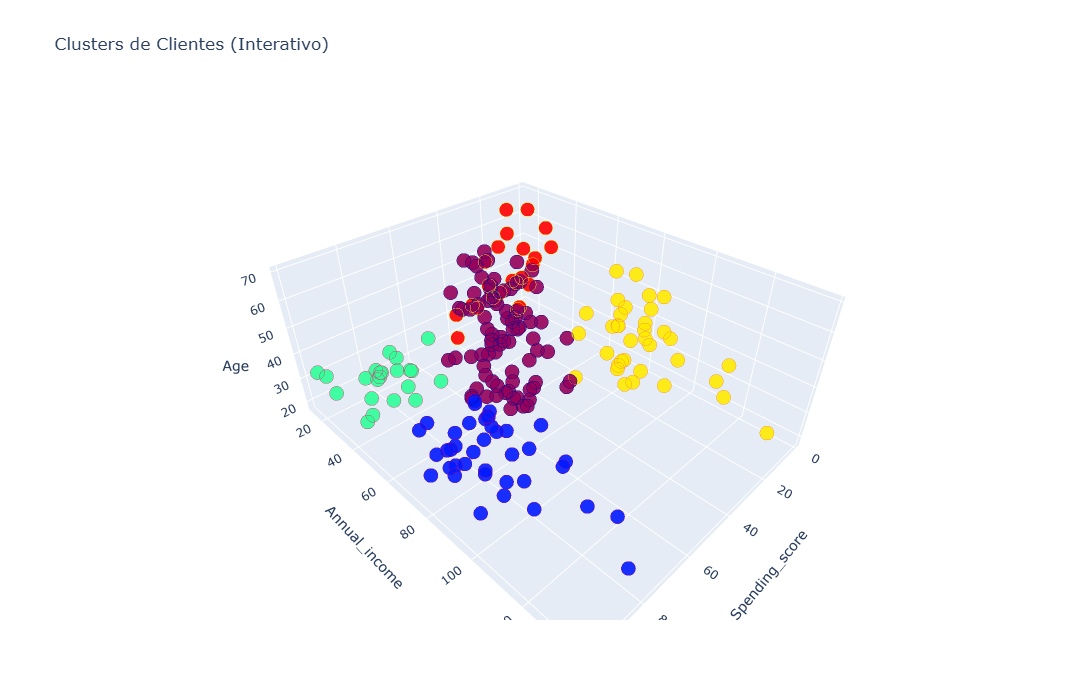

In [22]:
# Cria o gráfico 3D com clusters segmentados por cor
trace1 = go.Scatter3d(
    x=df['Spending_score'],  
    y=df['Annual_income'],    
    z=df['Age'],             
    mode='markers',
    marker=dict(
        color=df['Cluster'],          
        colorscale='Rainbow',        
        size=8,
        opacity=0.9,
        line=dict(
            color=df['Cluster'],
            width=1
        )
    )
)

layout = go.Layout(
    title='Clusters de Clientes (Interativo)',
    scene=dict(
        xaxis=dict(title='Spending_score'),
        yaxis=dict(title='Annual_income'),
        zaxis=dict(title='Age')
    ),
    width=900,
    height=700
)

fig = go.Figure(data=[trace1], layout=layout)
fig.show()


* <font color="teal">**Teal Cluster**</font> - Clientes jovens com renda anual baixa/moderada e com gasto elevado.
* <font color="blue">**Blue Cluster**</font> - Clientes razoavelmente jovens com salários muito bons que gastam bastante.
* <font color="purple">**Purple Cluster**</font> - Cliente de todas as idades cujo salário não é muito alto e a pontuação de gastos é moderada.
* <font color="#DD9900">**Yellow Cluster**</font> - Clientes com salários muito bons porém com gasto baixo (idade dispersa 30+)
* <font color="red">**Red Cluster**</font> - Clientes com salário muito baixo e que não gastam muito dinheiro em lojas (idades variadas).

Com estes insights podemos direcionar o time de estratégia comercial para atacar cada cliente de acordo com seu comportamento. Podemos assumir que:

* <font color="teal">**Teal Cluster**</font> - são bons clientes porém podem conter algum risco financeiro devido ao hábito de consumo poder ser incompatível com a renda. Podem reagir a melhoria no prazo de pagamento
* <font color="blue">**Blue Cluster**</font> - são os melhores clientes com renda e gasto elevado, devemos buscar a fidelização deste grupo com por exemplo vounchers de desconto ou de brindes recorrentes e escalonavéis com o volume de compra.
* <font color="purple">**Purple Cluster**</font> - provavelmente são clientes mais disciplinados com gasto compativel a renda - podem ser bons alvos de promoções
* <font color="#DD9900">**Yellow Cluster**</font> - clientes com potencial devido a renda porém sem custume de comprar - direcionar marketing para atrair
* <font color="red">**Red Cluster**</font> - clientes sem potencial e sem historico bom de compras - não investir em marketing para este cluster pois não deve trazer retorno.